## Final Model Development

This notebook focuses on building and evaluating the final optimized machine learning model for Parkinson’s disease prediction.


## Importing Required Libraries and Loading Dataset

The required Python libraries are imported for:

- Data manipulation
- Visualization
- Model training
- Hyperparameter tuning
- Performance evaluation
- Model serialization

The Parkinson’s dataset is then loaded for preprocessing and model development.

These steps initialize the complete machine learning workflow.

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

In [3]:
df = pd.read_csv('../data/selected_features.csv')
df.head()

,spread1,PPE,spread2,MDVP:Fo(Hz),status
0,-4.813031,0.284654,0.266482,119.992,1
1,-4.075192,0.368674,0.335590,122.400,1
2,-4.443179,0.332634,0.311173,116.682,1
3,-4.117501,0.368975,0.334147,116.676,1
4,-3.747787,0.410335,0.234513,116.014,1


In [4]:
df.shape

(195, 5)

## Feature and Target Definition

The selected input features are separated from the target variable (`status`).

### Selected Features

- spread1
- PPE
- spread2
- MDVP:Fo(Hz)

These features were selected based on their strong correlation with Parkinson’s disease prediction.

---

## Train-Test Split

The dataset is divided into training and testing sets to evaluate model generalization performance.

- Training Set Size: `(156, 4)`
- Testing Set Size: `(39, 4)`

The training data is used for model learning, while the testing data is used for performance evaluation on unseen samples.

In [5]:
X= df.drop('status', axis=1)
y = df['status']

print("Selected Features: ")
print(X.columns.tolist())

Selected Features: 
['spread1', 'PPE', 'spread2', 'MDVP:Fo(Hz)']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (156, 4)
Testing set size: (39, 4)


## Feature Scaling

Feature scaling is applied using `StandardScaler` to normalize the input features.

- The training data is fitted and transformed.
- The testing data is transformed using the same scaler.

This step improves model performance by ensuring all features are on a similar scale.

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Hyperparameter Tuning

Hyperparameter tuning is performed using `GridSearchCV` to identify the optimal Logistic Regression configuration.

The model is evaluated using different values of:

- Regularization strength (`C`)
- Optimization algorithm (`solver`)

Cross-validation (`cv=5`) is used to select the best parameter combination based on accuracy.

### Best Hyperparameters

- `C = 0.1`
- `solver = 'lbfgs'`

These parameters achieved the best classification performance during tuning.

In [8]:
params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}
grid = GridSearchCV(LogisticRegression(), param_grid = params, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)
print("Best Hyperparameters: ")
print(grid.best_params_)

Best Hyperparameters: 
{'C': 0.1, 'solver': 'lbfgs'}


## Final Model Training

The best-performing Logistic Regression model obtained from hyperparameter tuning is selected as the final model.

The model is then trained using the scaled training dataset to learn prediction patterns for Parkinson’s disease classification.

In [9]:
final_model = grid.best_estimator_

final_model.fit(
    X_train_scaled,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Model Prediction and Evaluation

The trained Logistic Regression model is used to predict Parkinson’s disease on the testing dataset.

### Performance Results

- Test Accuracy: `89.74%`
- Cross-Validation Accuracy: `85.22%`

### Classification Report Summary

- The model achieved high precision and recall for Parkinson’s positive cases.
- The overall classification performance indicates strong predictive capability.
- The model successfully identified most disease-positive samples with high reliability.

These results demonstrate that the model performs effectively on unseen data.

In [10]:
y_pred = final_model.predict(X_test_scaled)

In [11]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.8974


In [12]:
cv_score = cross_val_score(final_model, X_train_scaled, y_train, cv=5).mean()
print(f"Cross-Validation Accuracy: {cv_score:.4f}")

Cross-Validation Accuracy: 0.8522


In [13]:
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.43      0.60         7
           1       0.89      1.00      0.94        32

    accuracy                           0.90        39
   macro avg       0.94      0.71      0.77        39
weighted avg       0.91      0.90      0.88        39



## Confusion Matrix Analysis

The confusion matrix evaluates the prediction performance of the final Logistic Regression model.

| Actual / Predicted | Class 0 | Class 1 |
|---|---|---|
| Class 0 | 3 | 4 |
| Class 1 | 0 | 32 |

### Performance Summary

- **True Negative (TN) = 3**  
  Correctly predicted healthy cases.

- **False Positive (FP) = 4**  
  Healthy cases incorrectly classified as Parkinson’s.

- **False Negative (FN) = 0**  
  No Parkinson’s cases were missed by the model.

- **True Positive (TP) = 32**  
  Correctly predicted Parkinson’s cases.

### Key Observation

- The model achieved **100% recall** for Parkinson’s positive cases.
- No disease-positive samples were missed during prediction.
- The model shows strong sensitivity toward Parkinson’s detection.
- A few healthy samples were incorrectly predicted as positive due to class imbalance.

Overall, the model demonstrates effective disease detection capability with high predictive performance.

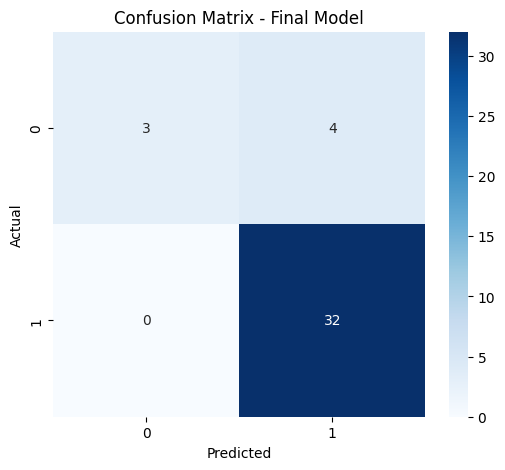

In [14]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Final Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Actual vs Predicted Comparison

The Actual vs Predicted plot visualizes the classification performance of the final model across individual test samples.

- The **Actual** values represent the true class labels.
- The **Predicted** values represent the model predictions.

### Key Observations

- Most predicted values correctly matched the actual labels.
- The model successfully identified all Parkinson’s positive cases.
- A few healthy samples were incorrectly classified as positive.
- Prediction errors are limited and randomly distributed across samples.

The plot confirms that the model achieved strong overall classification performance with high sensitivity toward disease detection.

In [15]:
# Actual vs Predicted Comparison
comparison_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
print("Actual vs Predicted Comparison:")
print(comparison_df.head(10))

Actual vs Predicted Comparison:
     Actual  Predicted
138       1          1
16        1          1
155       1          1
96        1          1
68        1          1
153       1          1
55        1          1
15        1          1
112       1          1
111       1          1


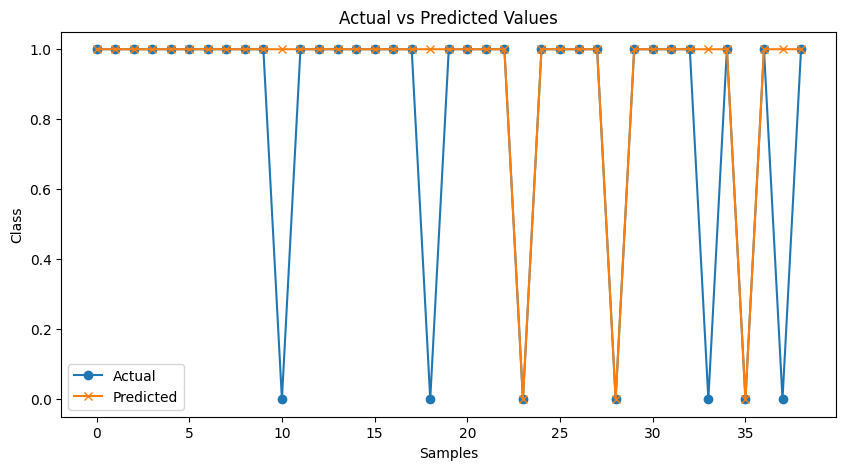

In [16]:
plt.figure(figsize=(10,5))

plt.plot(
    y_test.values,
    label="Actual",
    marker='o'
)

plt.plot(
    y_pred,
    label="Predicted",
    marker='x'
)

plt.title(
    "Actual vs Predicted Values"
)

plt.xlabel("Samples")

plt.ylabel("Class")

plt.legend()

plt.show()

## Feature Importance Analysis

Feature importance analysis is performed using the coefficients of the Logistic Regression model.

The coefficient values indicate how strongly each feature influences the prediction outcome.

| Feature | Coefficient | Impact |
|---|---|---|
| spread1 | 0.656477 | Strong Positive |
| PPE | 0.633085 | Strong Positive |
| spread2 | 0.419257 | Moderate Positive |
| MDVP:Fo(Hz) | -0.287805 | Negative |

### Key Observations

- `spread1` and `PPE` are the most influential features for Parkinson’s prediction.
- Positive coefficients increase the probability of predicting Parkinson’s disease.
- `MDVP:Fo(Hz)` shows a negative relationship with the target class.
- The model relies heavily on vocal frequency variation and speech irregularity features.

This analysis improves model interpretability and helps identify the most important predictive biomarkers.


Feature Coefficients:

       Feature  Coefficient
0      spread1     0.656477
1          PPE     0.633085
2      spread2     0.419257
3  MDVP:Fo(Hz)    -0.287805


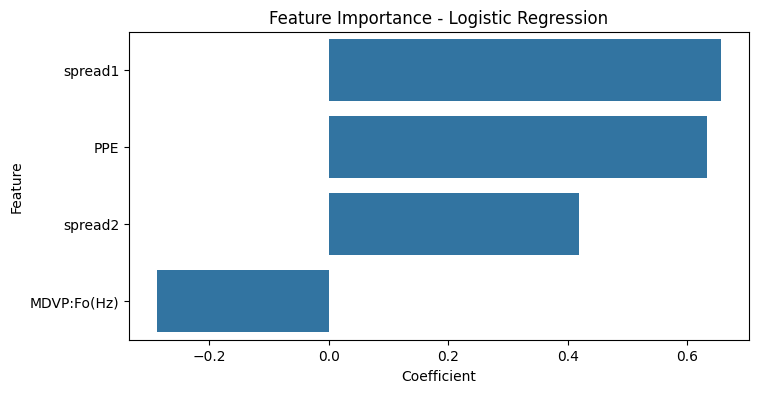

In [17]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient":
        final_model.coef_[0]
})

importance = importance.sort_values(

    by="Coefficient",

    ascending=False
)

print("\nFeature Coefficients:\n")

print(importance)

plt.figure(figsize=(8,4))

sns.barplot(x="Coefficient",y="Feature",data=importance)

plt.title("Feature Importance - Logistic Regression")

plt.show()


## Model Saving

The trained final Logistic Regression model is saved using `joblib`.

- Model File: `final_logistic_model.pkl`

Saving the model allows future predictions without retraining the model again.

This step supports deployment and real-world application integration.

In [18]:
joblib.dump(final_model, '../models/final_logistic_model.pkl')
print("Final model saved to '../models/final_logistic_model.pkl'")

Final model saved to '../models/final_logistic_model.pkl'


## Saving Prediction Results

The actual and predicted classification results are saved as a CSV file.

- Output File: `final_predictions.csv`

This file stores model prediction outputs for further analysis, reporting, and performance validation.

In [19]:
comparison_df.to_csv("../results/final_predictions.csv", index=False)

print("Prediction results saved successfully.")

Prediction results saved successfully.


# Final Conclusion

This project developed a machine learning model for Parkinson’s disease prediction using voice-based biomedical features.

The complete workflow included:

- Data preprocessing
- Exploratory Data Analysis (EDA)
- Feature selection
- Model training
- Model comparison
- Hyperparameter tuning
- Final model evaluation

Multiple machine learning algorithms were tested, and Logistic Regression achieved the best overall performance on the selected dataset.

The final model achieved:

- Test Accuracy: `89.74%`
- Cross-Validation Accuracy: `85.22%`

The results indicate that vocal biomarkers such as `spread1`, `PPE`, and `spread2` have significant influence in Parkinson’s disease prediction.

Although the model demonstrated strong predictive capability, the project also has certain limitations due to the small dataset size and class imbalance. Performance may improve with larger and more diverse real-world medical voice datasets.

In future work, the system can be extended by:

- Using larger clinical datasets
- Applying advanced ensemble models
- Integrating real-time voice input
- Developing a web-based prediction application
- Implementing automated voice feature extraction

Overall, this project demonstrates the practical application of machine learning techniques in medical prediction systems and provides a strong foundation for future AI-assisted healthcare solutions.